In [2]:
import pandas as pd 
all_vaults = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_list.csv")
all_vaults.head(2)
all_vaults = all_vaults['address'].unique()

In [6]:
import os 
market2vaults = {}
for d in os.listdir("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"):
    if "base_cbbtc" in d:
        if d != "base_cbbtc_usdc_full.csv":
            continue
    market_df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/" + d)
    market_addr = market_df['market_address'].unique()[0]
    vaults = market_df[market_df['user_address'].isin(all_vaults)]['user_address'].unique()
    market2vaults[market_addr] = vaults
    print(d, " - ", len(vaults))

eth_PT-syrupUSDC-28AUG2025_usdc.csv  -  9
eth_mF-ONE_usdc.csv  -  25
eth_PT-slvlUSD-25SEP2025_usdc.csv  -  12
eth_PT-USDe-27NOV2025_usds.csv  -  2
eth_fxsave_usdc.csv  -  19
base_wbtc_usdc.csv  -  42
base_wbtc_usdt.csv  -  23
eth_PT-USDe-25SEP2025_dai.csv  -  2
eth_PT-syrupUSDC-30OCT2025_usdc.csv  -  11
eth_PT-stcUSD-23JUL2026_usdc.csv  -  7
eth_syrupusdc_pyusd.csv  -  2
base_cbbtc_usdc_full.csv  -  68
eth_slvlusd_usdc.csv  -  15
eth_syrupusdc_usdc.csv  -  32
eth_PT-wstUSR-27MAR2025_usr.csv  -  2
eth_susde_pyusd.csv  -  2
eth_sdeusd_usdc.csv  -  12
eth_PT-sNUSD-5MAR2026_usdc.csv  -  7
PT-reUSD-25JUN2026_usdc.csv  -  17
eth_PT-USD0++-31OCT2024_usdc.csv  -  1
eth_PT-USDe-31JUL2025_dai.csv  -  2
eth_cbbtc_usdt.csv  -  8


/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_9133/15233413.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  market_df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/" + d)


eth_cbbtc_usdc.csv  -  50
eth_wsrusd_usdc.csv  -  1
eth_PT-USDe-25SEP2025_usdt.csv  -  9
eth_PT-USDe-25SEP2025_usdc.csv  -  18


/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_9133/15233413.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  market_df = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/" + d)


eth_rlp_usdc.csv  -  32
eth_PT-wstUSR-27MAR2025_usdc.csv  -  1
eth_PT-slvlUSD-29MAY2025_usdc.csv  -  4
eth_PT-mHYPER-20NOV2025_usdc.csv  -  6
eth_csusdl_usdc.csv  -  17
eth_mhyper_usdc.csv  -  18
eth_stcusd_usdc.csv  -  19
eth_PT-sdeUSD-1753142406_usdc.csv  -  9
eth_PT-reUSD-25JUN2026_usdc.csv  -  18
eth_wstusr_usdc.csv  -  23
eth_reusd_usdc.csv  -  14
eth_siusd_usdc.csv  -  18
eth_wbtc_usdc.csv  -  48
eth_wbtc_usdt.csv  -  23
eth_PT-reUSD-18DEC2025_usdc.csv  -  12
eth_usde_dai.csv  -  5
eth_PT-RLP-4SEP2025_usdc.csv  -  9
eth_usr_usdc.csv  -  12
eth_PT-csUSDL-31JUL2025_usdc.csv  -  9
PT-siUSD-26MAR2026_usdc.csv  -  6
eth_usd0++_usdc.csv  -  19
eth_weth_usdt.csv  -  7
eth_mapollo_usdc.csv  -  3
eth_wsteth_usdt.csv  -  18
eth_wsteth_usdc.csv  -  51
eth_PT-wstUSR-25SEP2025_usdc.csv  -  9
eth_PT-stcUSD-29JAN2026_usdc.csv  -  18
eth_PT-lvlUSD-29MAY2025_usdc.csv  -  5
eth_PT-USR-29MAY2025_usdc.csv  -  6
eth_PT-USDe-27MAR2025_dai.csv  -  4
eth_PT-USD0++-27MAR2025_usdc.csv  -  1


In [8]:
markets_vaults = []
for i in market2vaults.keys():
    markets_vaults += list(market2vaults[i])
markets_vaults = list(set(markets_vaults))
len(markets_vaults)

214

In [69]:
import requests 
MORPHO_GRAPHQL_API = "https://api.morpho.org/graphql"
import time
def query_aave_graphql(query):
    headers = {
        'Content-Type': 'application/json',
        'Access-Control-Allow-Origin': 'https://sandbox.embed.apollographql.com',
        'Access-Control-Allow-Credentials': 'true'
    }
    CNT = 0
    for I in range(10):
        try:
            response = requests.post(
                MORPHO_GRAPHQL_API,
                json={'query': query},
                headers=headers,
                timeout=100,
            )
            if response.status_code == 200:
                # print(response.json())
                return response.json()
        except Exception as e:
            pass
        print(f"Retrying, attempt {I+1}")
        time.sleep(5 + 5 * (I // 3))
    raise Exception(f"Query failed with status {response.status_code}: {response.text}")



In [15]:
from tqdm import tqdm_notebook
def fetch_vault_allocations(vault_addresses, query_func, delay=0.5):
    """
    For each vault address, fetch its allocation markets.

    Parameters:
    vault_addresses : list of str
    query_func : function that takes a GraphQL query string and returns JSON response
    delay : seconds between requests

    Returns:
    dict : vault_address -> list of market addresses (marketId)
    """
    results = {}
    for addr in tqdm_notebook(vault_addresses):
        query = f"""
        query {{
          vaultByAddress(
            address: "{addr}"
            chainId: 1
          ) {{
            address
            state {{
              totalAssets
              allocation {{
                market {{
                  marketId
                }}
              }}
            }}
          }}
        }}
        """
        resp = query_func(query)
        try:
            if resp and 'data' in resp:
                vault_data = resp['data'].get('vaultByAddress')
                if vault_data:
                    
                        allocations = vault_data.get('state', {}).get('allocation', [])
                        market_ids = [item['market']['marketId'] for item in allocations if 'market' in item]
                        results[addr] = market_ids
        except Exception as e:
            continue
        time.sleep(delay)
    return results

all_vaults_markets_allocations = fetch_vault_allocations(markets_vaults, query_aave_graphql)

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_9133/2430288112.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for addr in tqdm_notebook(vault_addresses):


  0%|          | 0/214 [00:00<?, ?it/s]

In [18]:
markets_to_fetch_util = []
for i in all_vaults_markets_allocations.keys():
    markets_to_fetch_util += list(all_vaults_markets_allocations[i])
markets_to_fetch_util = list(set(markets_to_fetch_util))
len(markets_to_fetch_util), len(all_vaults_markets_allocations)

(275, 146)

In [ ]:
yb_markets_addrs = ['0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9a479bd02a56041d4cf77',
       '0xb323495f7e4148be5643a4ea4a8221eef163e4bccfdedc2a6f4696baacbc86cc',
       '0xe1b65304edd8ceaea9b629df4c3c926a37d1216e27900505c04f14b2ed279f33',
       '0x1eda1b67414336cab3914316cb58339ddaef9e43f939af1fed162a989c98bc20',
       '0xc581c5f70bd1afa283eed57d1418c6432cbff1d862f94eaf58fdd4e46afbb67f',
       '0x95c28d447950ca6c8bbfd25fc05b80b1fd7a1cdd17a3610b4b3f1ffc8dc2e2ed',
       '0x729badf297ee9f2f6b3f717b96fd355fc6ec00422284ce1968e76647b258cf44',
       '0xd9e34b1eed46d123ac1b69b224de1881dbc88798bc7b70f504920f62f58f28cc',
       '0x8b1bc4d682b04a16309a8adf77b35de0c42063a7944016cfc37a79ccac0007b6',
       '0x83b7ad16905809ea36482f4fbf6cfee9c9f316d128de9a5da1952607d5e4df5e',
       '0xef2c308b5abecf5c8750a1aa82b47c558005feb7a03f4f8e1ad682d71ac8d0ba',
       '0x43e925e52d7873fa8acac90dd5f246087d55b3a34c344b71884a6352491ff459',
       '0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824f0803d0fc7704f60eaed',
       '0xbbf7ce1b40d32d3e3048f5cf27eeaa6de8cb27b80194690aab191a63381d8c99',
       '0xeb17955ea422baeddbfb0b8d8c9086c5be7a9cfdefb292119a102e981a30062e',
       '0x0f9563442d64ab3bd3bcb27058db0b0d4046a4c46f0acd811dacae9551d2b129',
       '0x90ef0c5a0dc7c4de4ad4585002d44e9d411d212d2f6258e94948beecf8b4c0d5',
       '0x1590cb22d797e226df92ebc6e0153427e207299916e7e4e53461389ad68272fb',
       '0x031c7333014af51e4fd18031d14e4eaada58348cde3f6dc6ea8cca16f7387fb2',
       '0xc9629945524f3fde56c7e8854a6c3d48e76b9d97236abbe73c750fcc7aeb8501']
interesting_vaults = []
for i in all_vaults_markets_allocations.keys():
    for c in yb_markets_addrs:
        if c in all_vaults_markets_allocations[i]:
            interesting_vaults.append(i)
            break

markets_to_fetch_util = []
for i in all_vaults_markets_allocations.keys():
    if i in interesting_vaults:
        markets_to_fetch_util += list(all_vaults_markets_allocations[i])
markets_to_fetch_util = list(set(markets_to_fetch_util))
len(markets_to_fetch_util), len(all_vaults_markets_allocations)

len(interesting_vaults), len(markets_to_fetch_util)

(101, 209)

In [70]:
import pandas as pd
import time
import json
import os
from datetime import datetime
from tqdm.auto import tqdm

def fetch_vaults_historical_supply(vault_addresses, query_func, delay=0.5, checkpoint_every=50, checkpoint_dir='./checkpoints'):
    """
    Resumeable fetch of historical supply per vault. Saves checkpoints.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, 'latest_checkpoint.json')
    
    # Load checkpoint if exists
    all_results = {}
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'r') as f:
            loaded = json.load(f)
            for vault, records in loaded.items():
                if records:
                    all_results[vault] = pd.DataFrame(records)
                else:
                    all_results[vault] = pd.DataFrame()
        print(f"Resumed from checkpoint: {len(all_results)} vaults loaded.")
    
    query_counter = 0
    # Determine which vaults we still need to process (if any missing)
    for vault in tqdm(vault_addresses, desc="Vaults"):
        if vault in all_results:
            # Vault already partially fetched – find earliest timestamp already present
            df_existing = all_results[vault]
            if not df_existing.empty:
                earliest_ts = df_existing['timestamp'].min()
                # We'll start from that timestamp - 1 month
                end_ts = earliest_ts - 1
            else:
                end_ts = int(datetime.now().timestamp())
        else:
            all_results[vault] = pd.DataFrame()
            end_ts = int(datetime.now().timestamp())
        
        vault_data = []  # list of new records to add later
        stop = False
        while not stop:
            start_ts = end_ts - 30 * 24 * 3600
            if start_ts < 0:
                break
            # Query
            query = f"""
            query {{
              vaultByAddress(
                address: "{vault}"
                chainId: 1
              ) {{
                address
                historicalState {{
                  allocation {{
                    market {{
                      marketId
                    }}
                    supplyAssetsUsd(options: {{
                      interval: HOUR
                      startTimestamp: {start_ts}
                      endTimestamp: {end_ts}
                    }}) {{
                      x
                      y
                    }}
                  }}
                }}
              }}
            }}
            """
            resp = query_func(query)
            query_counter += 1
            
            # Checkpoint occasionally
            if query_counter % checkpoint_every == 0:
                # Save current state (convert DataFrames to records)
                save_dict = {k: df.to_dict('records') for k, df in all_results.items()}
                with open(checkpoint_path, 'w') as f:
                    json.dump(save_dict, f, default=str)
            
            if resp and 'data' in resp:
                vault_data_resp = resp['data'].get('vaultByAddress')
                if vault_data_resp:
                    historical = vault_data_resp.get('historicalState', {})
                    allocations = historical.get('allocation', [])
                    any_data = False
                    for alloc in allocations:
                        market_id = alloc['market']['marketId']
                        supply_series = alloc.get('supplyAssetsUsd', [])
                        if supply_series:
                            any_data = True
                            for point in supply_series:
                                vault_data.append({
                                    'vault_address': vault,
                                    'market_address': market_id,
                                    'timestamp': point['x'],
                                    'datetime': pd.to_datetime(point['x'], unit='s'),
                                    'supply_usd': point['y']
                                })
                    if not any_data:
                        stop = True
                else:
                    stop = True
            else:
                stop = True
            
            end_ts = start_ts - 1
            time.sleep(delay)
        
        # Merge new data into all_results
        if vault_data:
            new_df = pd.DataFrame(vault_data)
            if all_results[vault].empty:
                all_results[vault] = new_df
            else:
                all_results[vault] = pd.concat([all_results[vault], new_df], ignore_index=True).drop_duplicates(subset=['timestamp', 'market_address'])
    
    # Final checkpoint
    save_dict = {k: df.to_dict('records') for k, df in all_results.items()}
    with open(checkpoint_path, 'w') as f:
        json.dump(save_dict, f, default=str)
    
    return all_results

vault_results = fetch_vaults_historical_supply(
    vault_addresses=interesting_vaults,
    query_func=query_aave_graphql,
    checkpoint_dir="./data/checkpoints"
)
vault_results.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_alloc_by_markets.csv", index=False)

Resumed from checkpoint: 49 vaults loaded.


Vaults:   0%|          | 0/101 [00:00<?, ?it/s]

Retrying, attempt 1
Retrying, attempt 1
Retrying, attempt 1


AttributeError: 'dict' object has no attribute 'to_csv'

In [88]:
all_records = []
for vault, df in vault_results.items():
    if not df.empty:
        all_records.append(df)

if all_records:
    combined_df = pd.concat(all_records, ignore_index=True)
else:
    combined_df = pd.DataFrame()

combined_df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_alloc_by_markets.csv", index=False)
combined_df.head()

,vault_address,market_address,timestamp,supply_usd,datetime
0,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777755600,2056.833153,NaT
1,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777752000,2056.890261,NaT
2,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777748400,2056.787254,NaT
3,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777744800,2056.758249,NaT
4,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777741200,2056.770784,NaT


In [89]:
combined_df.shape

(14114446, 5)

In [67]:
import json 
with open("./data/checkpoints/checkpoint_600.json", 'r') as f:
    loaded = json.load(f)


In [68]:
loaded.keys()

dict_keys(['0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb', '0x7193794ec82f527Efb618Ac50C078D348eCBA4b6', '0xbeeFfF68CC520D68f82641EFF84330C631E2490E', '0x68Aea7b82Df6CcdF76235D46445Ed83f85F845A3', '0x13AA4f80AD5F06cE4f1A3a3cA58C37059F0EE4c5', '0xBEefb9f61CC44895d8AEc381373555a64191A9c4', '0x73Ea4fff78a427d8b9bd77216aF4c42e78E2F5b8', '0x4cA0E178c94f039d7F202E09d8d1a655Ed3fb6b6', '0xfD1241C4fc37680De370dDc20eBF7bC5e561E1c1', '0xEbFA750279dEfa89b8D99bdd145a016F6292757b', '0xef0B6b77E014A9EB897b56466ea53175E14B9F34', '0xFB219e20e7Ad26345FD3474EBA6C9250482971Cf', '0x8F40e713a1Cfeff2A052E0c610C8118Be3f75b12', '0xf29ce940178C8794802fB48a6c1B2EdDdAC96431', '0x3bc4697F484F48f219B3f1Fdd2AD39cb3e986923', '0xE01813b0A12B14CC13BD5E9F0E8a2Aa7543617a1', '0xd63070114470f685b75B74D60EEc7c1113d33a3D', '0x64964E162Aa18d32f91eA5B24a09529f811AEB8e', '0x09C4C7B1D2e9Aa7506db8B76f1dBbD61c08c114b', '0x38Bc32F98c6D5C2Bb8c743a4Aa364b4F529fD1Ac', '0xbeEf96B330ef1Fe7Ebe41eCe0Bd4a41A94Bc03DC', '0x4F2ba48FaF0bA42c4E4b

In [65]:
vr = vault_results['0xdd0f28e19C1780eb6396170735D45153D261490d']
vr[vr['market_address'].str.startswith("0x3a85e")]

,vault_address,market_address,timestamp,datetime,supply_usd
0,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777755600,2026-05-02 21:00:00,4.903712e+07
1,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777752000,2026-05-02 20:00:00,4.903870e+07
2,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777748400,2026-05-02 19:00:00,4.924078e+07
3,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777744800,2026-05-02 18:00:00,4.899891e+07
4,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1777741200,2026-05-02 17:00:00,4.883483e+07
...,...,...,...,...,...
93785,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1709697600,2024-03-06 04:00:00,NaN
93786,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1709694000,2024-03-06 03:00:00,NaN
93787,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1709690400,2024-03-06 02:00:00,NaN
93788,0xdd0f28e19C1780eb6396170735D45153D261490d,0x3a85e619751152991742810df6ec69ce473daef99e28...,1709686800,2024-03-06 01:00:00,NaN


In [83]:
def fetch_markets_utilization(market_addresses, query_func, delay=0.5):
    """
    Fetch hourly utilization and total supply (liquidity) for a list of market addresses via GraphQL.

    Parameters:
    market_addresses : list of str
    query_func : function that takes a GraphQL query string and returns the JSON response
    delay : seconds to wait between requests (to avoid rate limiting)

    Returns:
    dict : market_address -> DataFrame with columns: market_address, timestamp, datetime, utilization, total_supply
    """
    results = {}
    for addr in tqdm_notebook(market_addresses):
        query = f"""
        query MarketApys {{
          marketById(
            marketId: "{addr}"
            chainId: 1
          ) {{
            marketId
            historicalState {{
              utilization(options: {{
                interval: HOUR
              }}) {{
                x
                y
              }}
              supplyAssetsUsd(options: {{
                interval: HOUR
              }}) {{
                x
                y
              }}
            }}
          }}
        }}
        """
        resp = query_func(query)
        if resp and 'data' in resp:
            market_data = resp['data'].get('marketById')
            if market_data:
                historical = market_data.get('historicalState', {})
                
                # Process utilization
                util_series = historical.get('utilization', [])
                supply_series = historical.get('supplyAssetsUsd', [])
                
                if util_series and supply_series:
                    # Convert to DataFrames and merge on timestamp (x)
                    df_util = pd.DataFrame(util_series).rename(columns={'x': 'timestamp', 'y': 'utilization'})
                    df_supply = pd.DataFrame(supply_series).rename(columns={'x': 'timestamp', 'y': 'total_supply'})
                    df = pd.merge(df_util, df_supply, on='timestamp', how='outer')
                    df['market_address'] = market_data['marketId']
                    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
                    results[addr] = df[['market_address', 'timestamp', 'datetime', 'utilization', 'total_supply']]
                elif util_series:
                    # Fallback: only utilization
                    df = pd.DataFrame(util_series).rename(columns={'x': 'timestamp', 'y': 'utilization'})
                    df['market_address'] = market_data['marketId']
                    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
                    df['total_supply'] = None
                    results[addr] = df[['market_address', 'timestamp', 'datetime', 'utilization', 'total_supply']]
        time.sleep(delay)
    return results

In [90]:
market2util_hist = fetch_markets_utilization(markets_to_fetch_util, query_aave_graphql)


/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_9133/2472613003.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for addr in tqdm_notebook(market_addresses):


  0%|          | 0/209 [00:00<?, ?it/s]

In [91]:
vault_markets_hist_supply = []
for vault, df in market2util_hist.items():
    if not df.empty:
        vault_markets_hist_supply.append(df)

vault_markets_hist_supply = pd.concat(vault_markets_hist_supply, ignore_index=True)

vault_markets_hist_supply.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vault_markets_hist_supply.csv", index=False)
vault_markets_hist_supply.head()

,market_address,timestamp,datetime,utilization,total_supply
0,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710421200,2024-03-14 13:00:00,0.0,0.0
1,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710424800,2024-03-14 14:00:00,0.0,0.0
2,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710428400,2024-03-14 15:00:00,0.0,0.0
3,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710432000,2024-03-14 16:00:00,0.0,0.0
4,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710435600,2024-03-14 17:00:00,0.0,0.0


In [ ]:
vault_markets_hist_supply = vault_markets_hist_supply.rename(columns={
    "utilization": "market_utilization",
    "total_supply": "market_total_supply",    
})
vault_markets_hist_supply = vault_markets_hist_supply.drop(columns=['datetime'])
vault_markets_hist_supply.head()

,market_address,timestamp,market_utilization,market_total_supply
0,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710421200,0.0,0.0
1,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710424800,0.0,0.0
2,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710428400,0.0,0.0
3,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710432000,0.0,0.0
4,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710435600,0.0,0.0


In [98]:
combined_df.head()
# vault_markets_hist_supply[vault_markets_hist_supply['market_address'].str.startswith('0x4565ac05d38b19') & (vault_markets_hist_supply['timestamp'] == 1777752000)]

,vault_address,market_address,timestamp,supply_usd,datetime
0,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777755600,2056.833153,NaT
1,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777752000,2056.890261,NaT
2,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777748400,2056.787254,NaT
3,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777744800,2056.758249,NaT
4,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777741200,2056.770784,NaT


In [97]:
vault_markets_hist_supply.drop_duplicates(['market_address', 'timestamp']).shape, vault_markets_hist_supply.shape

((1567592, 5), (1567592, 5))

In [ ]:

unified = combined_df.merge(vault_markets_hist_supply, how='left', on=["market_address", "timestamp"]).drop(columns=['datetime'])
unified.head()

,vault_address,market_address,timestamp,supply_usd,datetime,market_utilization,market_total_supply
0,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777755600,2056.833153,NaT,0.873347,4.701860e+06
1,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777752000,2056.890261,NaT,0.873346,4.701991e+06
2,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777748400,2056.787254,NaT,0.873345,4.701755e+06
3,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777744800,2056.758249,NaT,0.914343,4.490867e+06
4,0xA1FF9C28Ebc160c1Dcde4b9aA9551f617880c6fb,0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824...,1777741200,2056.770784,NaT,0.914342,4.490894e+06


In [168]:
unified['vault_address'].value_counts()

vault_address
0xd63070114470f685b75B74D60EEc7c1113d33a3D    1149516
0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458    1053420
0xBEeFFF209270748ddd194831b3fa287a5386f5bC     997677
0x777791C4d6DC2CE140D00D2828a7C93503c67777     870996
0xc582F04d8a82795aa2Ff9c8bb4c1c889fe7b754e     673379
                                               ...   
0x81AE586dE7876a4C06163bEe0598AD2471E67322      11079
0xB352fd86B73D72bc16817aa101dfB1C03C95Bd24       8876
0xef0B6b77E014A9EB897b56466ea53175E14B9F34       8806
0x87cb57D154ED695c4652ed755D49D7C99708b943       6150
0x29F2Cbc1e6F3250e008f91b3FFA5ffa7C460a0Fc       3429
Name: count, Length: 101, dtype: int64

In [ ]:
import numpy as np
unified['market_free_liquidity'] = unified['market_total_supply'] * (1-unified['market_utilization'])

def add_stress_indices(df, lambda_=1.0, gamma=2.0, u_c=0.9, epsilon=1e-8):
    df = df.copy()
    df.loc[df['market_utilization'] == 0, 'market_utilization'] = 0.9
    df['supply_usd'] = df['supply_usd'].fillna(0)
    u = df['market_utilization']
    S = df['market_total_supply'].fillna(0)
    

    # Market stress index
    denominator = (1 - u + epsilon) * np.log1p(S)
    penalty = 1 + lambda_ * np.maximum(0, u - u_c) ** gamma
    df['market_stress_index'] = np.log1p((u / ((1 - u + epsilon) * np.log1p(S))) * penalty)

    # Total supply per vault per timestamp
    df['total_supply_vault'] = df.groupby(['vault_address', 'timestamp'])['supply_usd'].transform('sum')
    df['weight'] = df['supply_usd'] / (df['total_supply_vault'] + epsilon)

    # Weighted stress per row
    df['weighted_stress'] = df['weight'] * df['market_stress_index']

    # Vault stress index: sum of weighted_stress per (vault, timestamp)
    df['vault_stress_index'] = df.groupby(['vault_address', 'timestamp'])['weighted_stress'].transform('sum')

    # Drop temporary columns if desired
    df.drop([], axis=1, inplace=True)

    return df[df["weight"] > 0.001].dropna()

unified_stress = add_stress_indices(unified[unified['vault_address'] == '0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458'])
unified_stress.head()
# unified.head()

,vault_address,market_address,timestamp,supply_usd,datetime,market_utilization,market_total_supply,market_free_liquidity,market_stress_index,total_supply_vault,weight,weighted_stress,vault_stress_index
7493312,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1775512800,12722.273672,2026-04-06 22:00:00,0.743644,15836.194139,4059.700725,0.262348,1.148334e+07,0.001108,0.000291,0.258705
7493313,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1775509200,12721.936774,2026-04-06 21:00:00,0.925501,12724.114978,947.937877,0.839525,1.148304e+07,0.001108,0.000930,0.264638
7493314,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1775505600,12720.681390,2026-04-06 20:00:00,0.925500,12722.859379,947.848410,0.839528,1.148191e+07,0.001108,0.000930,0.260485
7493315,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1775502000,12720.787785,2026-04-06 19:00:00,0.925500,12722.965792,947.860406,0.839525,1.148200e+07,0.001108,0.000930,0.304860
7493316,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1775498400,12717.928694,2026-04-06 18:00:00,0.925500,12720.106212,947.651429,0.839536,1.147942e+07,0.001108,0.000930,0.356518


In [186]:
from tqdm import tqdm_notebook
all_vaults_w_stress_indices = []
for v in tqdm_notebook(unified['vault_address'].unique()):
    all_vaults_w_stress_indices.append(add_stress_indices(unified[unified['vault_address'] == v]))
all_vaults_w_stress_indices = pd.concat(all_vaults_w_stress_indices, ignore_index=True)
all_vaults_w_stress_indices.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_w_stress.csv", index=False)

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_9133/3489576466.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for v in tqdm_notebook(unified['vault_address'].unique()):


  0%|          | 0/101 [00:00<?, ?it/s]

In [190]:
'0xd63070114470f685b75B74D60EEc7c1113d33a3D' in interesting_vaults, all_vaults_w_stress_indices['vault_address'].unique()

(True,
 array(['0xC59928341D08fEf900C6FA847fA9D775D27e482f',
        '0x2Ccb3717b04Df3603b1471738d4d500Fa8e57b85',
        '0x19b3cD7032B8C062E8d44EaCad661a0970DD8c55',
        '0xB352fd86B73D72bc16817aa101dfB1C03C95Bd24',
        '0xbEeF1898443D2eB9C9C471e073f46A3928dB21dE',
        '0xc582F04d8a82795aa2Ff9c8bb4c1c889fe7b754e',
        '0x3FA495ecB30E4910bAC2a31818fd68d0DBb042a4',
        '0x94643e86aa5E38DDAc6c7791C1297f4E40cD96c1',
        '0x87cb57D154ED695c4652ed755D49D7C99708b943',
        '0x56A76b428244a50513ec81e225a293d128fd581D',
        '0x29F2Cbc1e6F3250e008f91b3FFA5ffa7C460a0Fc',
        '0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458',
        '0x73e65DBD630f90604062f6E02fAb9138e713edD9',
        '0x62067831C193810F3b044Cc42249632b5d08Bc6b',
        '0xF2eFEBE45180C8c04edFdBfF3d88e58C9D61a03E',
        '0xe108fbc04852B5df72f9E44d7C29F47e7A993aDd',
        '0x214B47C50057eFaa7adc1B1C2608C3751Cd77D78',
        '0x777791C4d6DC2CE140D00D2828a7C93503c67777',
        '0x62578B2C96

In [184]:
pd.set_option('display.max_colwidth', None)

unified_stress[unified_stress['vault_stress_index'] > 20]
unified_stress[unified_stress['timestamp'] == 1774188000].dropna().sort_values("weight", ascending=False)

,vault_address,market_address,timestamp,supply_usd,datetime,market_utilization,market_total_supply,market_free_liquidity,market_stress_index,total_supply_vault,weight,weighted_stress,vault_stress_index
7536160,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x27b9a0a5bfee98a31eb51e3850250d103a9f8e41673c782defc66aa943af0e65,1774188000,8.064519e+06,2026-03-22 14:00:00,1.0,1.209533e+07,0.0,15.638955,2.811471e+07,0.286843,4.485931,15.63937
7572880,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xeb17955ea422baeddbfb0b8d8c9086c5be7a9cfdefb292119a102e981a30062e,1774188000,7.601361e+06,2026-03-22 14:00:00,1.0,1.661006e+07,0.0,15.619692,2.811471e+07,0.270370,4.223089,15.63937
7567840,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xd9e34b1eed46d123ac1b69b224de1881dbc88798bc7b70f504920f62f58f28cc,1774188000,4.955460e+06,2026-03-22 14:00:00,1.0,6.225612e+06,0.0,15.680532,2.811471e+07,0.176259,2.763829,15.63937
7562080,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xbbf7ce1b40d32d3e3048f5cf27eeaa6de8cb27b80194690aab191a63381d8c99,1774188000,4.381738e+06,2026-03-22 14:00:00,1.0,4.576216e+07,0.0,15.560521,2.811471e+07,0.155852,2.425141,15.63937
7564960,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xbf02d6c6852fa0b8247d5514d0c91e6c1fbde9a168ac3fd2033028b5ee5ce6d0,1774188000,1.334967e+06,2026-03-22 14:00:00,1.0,4.085825e+06,0.0,15.707822,2.811471e+07,0.047483,0.745853,15.63937
7544800,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x61765602144e91e5ac9f9e98b8584eae308f9951596fd7f5e0f59f21cd2bf664,1774188000,9.917427e+05,2026-03-22 14:00:00,1.0,1.981207e+06,0.0,15.756537,2.811471e+07,0.035275,0.555810,15.63937
7571440,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe83d72fa5b00dcd46d9e0e860d95aa540d5ec106da5833108a9f826f21f36f52,1774188000,3.120388e+05,2026-03-22 14:00:00,1.0,4.577305e+07,0.0,15.560507,2.811471e+07,0.011099,0.172703,15.63937
7568560,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xdb8938f97571aeab0deb0c34cf7e6278cff969538f49eebe6f4fc75a9a111293,1774188000,3.009438e+05,2026-03-22 14:00:00,1.0,4.981612e+05,0.0,15.856594,2.811471e+07,0.010704,0.169731,15.63937
7570720,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe4cfbee9af4ad713b41bf79f009ca02b17c001a0c0e7bd2e6a89b1111b3d3f08,1774188000,8.946895e+04,2026-03-22 14:00:00,1.0,6.799968e+05,0.0,15.833152,2.811471e+07,0.003182,0.050386,15.63937
7552000,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x85c7f4374f3a403b36d54cc284983b2b02bbd8581ee0f3c36494447b87d9fcab,1774188000,8.246906e+04,2026-03-22 14:00:00,1.0,9.876065e+04,0.0,15.988244,2.811471e+07,0.002933,0.046898,15.63937


In [177]:
unified_stress[(unified_stress['vault_stress_index'] > 10) & (np.abs(unified_stress['vault_stress_index'] - unified_stress['weighted_stress']) > 0.01)]


,vault_address,market_address,timestamp,supply_usd,datetime,market_utilization,market_total_supply,market_free_liquidity,market_stress_index,total_supply_vault,weight,weighted_stress,vault_stress_index
7531840,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x05702edf1c4709808b62fe65a7d082dccc9386f858ae...,1774188000,0.0,2026-03-22 14:00:00,1.000000,1571.153112,0.000000,16.434544,2.811471e+07,0.0,0.0,15.639370
7531841,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x05702edf1c4709808b62fe65a7d082dccc9386f858ae...,1774184400,0.0,2026-03-22 13:00:00,1.000000,1571.083881,0.000000,16.434550,3.283547e+07,0.0,0.0,15.617321
7531842,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x05702edf1c4709808b62fe65a7d082dccc9386f858ae...,1774180800,0.0,2026-03-22 12:00:00,1.000000,1570.903007,0.000000,16.434565,3.288261e+07,0.0,0.0,13.920302
7531843,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x05702edf1c4709808b62fe65a7d082dccc9386f858ae...,1774177200,0.0,2026-03-22 11:00:00,1.000000,1570.898872,0.000000,16.434566,3.338693e+07,0.0,0.0,15.615370
7531844,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0x05702edf1c4709808b62fe65a7d082dccc9386f858ae...,1774173600,0.0,2026-03-22 10:00:00,1.000000,1570.871070,0.000000,16.434568,3.338837e+07,0.0,0.0,15.615370
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8520898,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe4cfbee9af4ad713b41bf79f009ca02b17c001a0c0e7...,1717963200,0.0,2024-06-09 20:00:00,0.900212,1.002135,0.100001,2.638695,4.873121e+06,0.0,0.0,12.092146
8520989,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe4cfbee9af4ad713b41bf79f009ca02b17c001a0c0e7...,1717635600,0.0,2024-06-06 01:00:00,0.900165,1.001651,0.100000,2.638529,1.411910e+06,0.0,0.0,10.598071
8520990,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe4cfbee9af4ad713b41bf79f009ca02b17c001a0c0e7...,1717632000,0.0,2024-06-06 00:00:00,0.900164,1.001172,0.099953,2.638844,1.411171e+06,0.0,0.0,10.597900
8520991,0x8eB67A509616cd6A7c1B3c8C21D48FF57df3d458,0xe4cfbee9af4ad713b41bf79f009ca02b17c001a0c0e7...,1717628400,0.0,2024-06-05 23:00:00,0.900164,1.001364,0.099972,2.638711,1.410378e+06,0.0,0.0,10.604904


In [133]:
unified_stress[unified_stress['market_address'].str.startswith("0x4565ac05d38b19374ccbb04c17cc")]['market_address'].unique()

array(['0x4565ac05d38b19374ccbb04c17cca60ca9353cd41824f0803d0fc7704f60eaed'],
      dtype=object)

<Axes: >

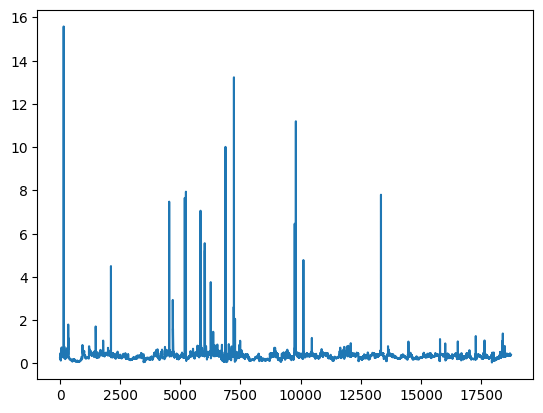

In [187]:
all_vaults_w_stress_indices[all_vaults_w_stress_indices['vault_address'] == '0xdd0f28e19C1780eb6396170735D45153D261490d'].drop_duplicates("timestamp").sort_values("timestamp").reset_index()['vault_stress_index'].clip(0,20).plot()

<Axes: >

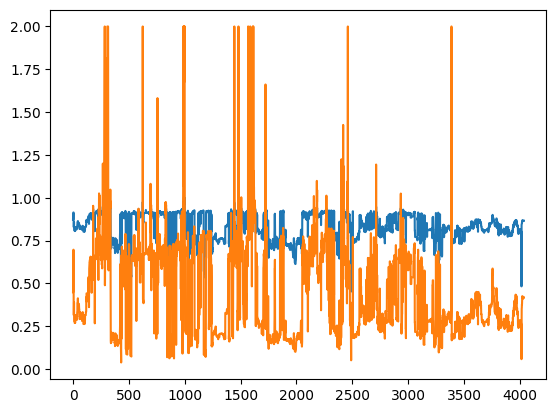

In [135]:
import matplotlib.pyplot as plt
ss = unified_stress[unified_stress['market_address'].str.startswith("0x4565ac05d38b19374ccbb04c17cc")][[
    'market_utilization',
    'market_free_liquidity',
    'market_stress_index'
]].clip(0,2).reset_index()[:1000000]
ss['market_utilization'].plot()
ss['market_stress_index'].plot()
# plt.hlines(y=1,xmin=0,xmax=1000000)


In [87]:
market2util_hist['0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88c7cdc5d6109fb0026b28']

,market_address,timestamp,datetime,utilization,total_supply
0,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710421200,2024-03-14 13:00:00,0.000000,0.000000
1,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710424800,2024-03-14 14:00:00,0.000000,0.000000
2,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710428400,2024-03-14 15:00:00,0.000000,0.000000
3,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710432000,2024-03-14 16:00:00,0.000000,0.000000
4,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710435600,2024-03-14 17:00:00,0.000000,0.000000
...,...,...,...,...,...
18715,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777795200,2026-05-03 08:00:00,0.897758,819039.894358
18716,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777798800,2026-05-03 09:00:00,0.897759,818964.828128
18717,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777802400,2026-05-03 10:00:00,0.897760,818954.951210
18718,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777806000,2026-05-03 11:00:00,0.897761,818962.236916


In [44]:
market2util_hist.keys()
market2util_hist['0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88c7cdc5d6109fb0026b28']
# market2util_hist['0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88c7cdc5d6109fb0026b28'].shape

,market_address,timestamp,datetime,utilization,liquidity
0,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710421200,2024-03-14 13:00:00,0.000000,0.000000
1,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710424800,2024-03-14 14:00:00,0.000000,0.000000
2,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710428400,2024-03-14 15:00:00,0.000000,0.000000
3,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710432000,2024-03-14 16:00:00,0.000000,0.000000
4,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1710435600,2024-03-14 17:00:00,0.000000,0.000000
...,...,...,...,...,...
18690,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777705200,2026-05-02 07:00:00,0.846162,133628.866612
18691,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777708800,2026-05-02 08:00:00,0.931979,53645.434347
18692,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777712400,2026-05-02 09:00:00,0.931980,53643.805252
18693,0x1247f1c237eceae0602eab1470a5061a6dd8f734ba88...,1777716000,2026-05-02 10:00:00,0.931981,53643.805252


In [47]:
def create_united_utilization_df(market_util_df, vault_allocations):
    """
    market_util_df: DataFrame with columns market_address, timestamp, datetime, utilization
    vault_allocations: dict {vault_address: list_of_market_addresses}
    
    Returns DataFrame with columns: vault_address, market_address, timestamp, datetime, utilization
    """
    records = []
    for vault, markets in vault_allocations.items():
        for market in markets:
            # Filter utilization data for this market
            subset = market_util_df[market] 
            subset['vault_address'] = vault
            records.append(subset)
    if not records:
        return pd.DataFrame(columns=['vault_address', 'market_address', 'timestamp', 'datetime', 'utilization', 'liquidity'])
    return pd.concat(records, ignore_index=True).sort_values(["vault_address", "market_address", "timestamp"])
unified_df = create_united_utilization_df(
    market2util_hist,
    all_vaults_markets_allocations
)
unified_df.head()

,market_address,timestamp,datetime,utilization,liquidity,vault_address
846860,0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5...,1756407600,2025-08-28 19:00:00,0.0,0.999816,0x018f8f5F52AAfF23FF838aE4637aFe22713FB428
6692027,0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5...,1756407600,2025-08-28 19:00:00,0.0,0.999816,0x018f8f5F52AAfF23FF838aE4637aFe22713FB428
10215281,0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5...,1756407600,2025-08-28 19:00:00,0.0,0.999816,0x018f8f5F52AAfF23FF838aE4637aFe22713FB428
10827271,0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5...,1756407600,2025-08-28 19:00:00,0.0,0.999816,0x018f8f5F52AAfF23FF838aE4637aFe22713FB428
846861,0x03f715ef1ae508ab3e1faf4dffdbf2a077d1f0ad10c5...,1756411200,2025-08-28 20:00:00,0.0,0.999817,0x018f8f5F52AAfF23FF838aE4637aFe22713FB428


In [48]:
unified_df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/vaults_allocation_states.csv", index=False)

In [54]:
unified_df[unified_df['vault_address'] == '0xdd0f28e19C1780eb6396170735D45153D261490d']['market_address'].unique()

array(['0x3a85e619751152991742810df6ec69ce473daef99e28a64ab2340d7b7ccfee49',
       '0x54efdee08e272e929034a8f26f7ca34b1ebe364b275391169b28c6d7db24dbc8',
       '0x64d65c9a2d91c36d56fbc42d69e979335320169b3df63bf92789e2c8883fcc64',
       '0xb323495f7e4148be5643a4ea4a8221eef163e4bccfdedc2a6f4696baacbc86cc'],
      dtype=object)

In [55]:
unified_df[
    (unified_df['vault_address'] == '0xdd0f28e19C1780eb6396170735D45153D261490d') & 
    (unified_df['market_address'] == '0x64d65c9a2d91c36d56fbc42d69e979335320169b3df63bf92789e2c8883fcc64')
]

,market_address,timestamp,datetime,utilization,liquidity,vault_address
164035,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1725480000,2024-09-04 20:00:00,0.000000,0.000000e+00,0xdd0f28e19C1780eb6396170735D45153D261490d
365360,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1725480000,2024-09-04 20:00:00,0.000000,0.000000e+00,0xdd0f28e19C1780eb6396170735D45153D261490d
499102,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1725480000,2024-09-04 20:00:00,0.000000,0.000000e+00,0xdd0f28e19C1780eb6396170735D45153D261490d
558227,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1725480000,2024-09-04 20:00:00,0.000000,0.000000e+00,0xdd0f28e19C1780eb6396170735D45153D261490d
654053,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1725480000,2024-09-04 20:00:00,0.000000,0.000000e+00,0xdd0f28e19C1780eb6396170735D45153D261490d
...,...,...,...,...,...,...
12190254,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1777717607,2026-05-02 10:26:47,0.897248,2.810546e+07,0xdd0f28e19C1780eb6396170735D45153D261490d
12300115,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1777717607,2026-05-02 10:26:47,0.897248,2.810546e+07,0xdd0f28e19C1780eb6396170735D45153D261490d
12736119,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1777717607,2026-05-02 10:26:47,0.897248,2.810546e+07,0xdd0f28e19C1780eb6396170735D45153D261490d
12828651,0x64d65c9a2d91c36d56fbc42d69e979335320169b3df6...,1777717607,2026-05-02 10:26:47,0.897248,2.810546e+07,0xdd0f28e19C1780eb6396170735D45153D261490d


In [51]:
unified_df['vault_address'].unique()

array(['0x018f8f5F52AAfF23FF838aE4637aFe22713FB428',
       '0x0562AE950276B24F3eAE0d0a518dADB7Ad2F8D66',
       '0x0B6C8ef0DE1Be5ed1B59E6e7a67fB9442FB9E49C',
       '0x0C36327e93F749a7eec04603410dF776150f47DE',
       '0x0F359FD18BDa75e9c49bC027E7da59a4b01BF32a',
       '0x13AA4f80AD5F06cE4f1A3a3cA58C37059F0EE4c5',
       '0x19b3cD7032B8C062E8d44EaCad661a0970DD8c55',
       '0x1E2aAaDcF528b9cC08F43d4fd7db488cE89F5741',
       '0x214B47C50057eFaa7adc1B1C2608C3751Cd77D78',
       '0x2C793f5cB25B35A99648783c01E6cCCC200D2096',
       '0x2Ccb3717b04Df3603b1471738d4d500Fa8e57b85',
       '0x2E87d6bfA3F2A932e0c70A32607c0B839404984D',
       '0x341193ED21711472e71aECa4A942123452bd0ddA',
       '0x38248d715336d4CAd20d3e12E8dc34DA596f9d6c',
       '0x3bc4697F484F48f219B3f1Fdd2AD39cb3e986923',
       '0x42D425Fb918acBbd73B10B851979E8fc469B3e9A',
       '0x4cA0E178c94f039d7F202E09d8d1a655Ed3fb6b6',
       '0x500331c9fF24D9d11aee6B07734Aa72343EA74a5',
       '0x5085Dd6FAd07c12e38fae01bc2a4938d2C08